# Ablation Study — Bám sát Bảng 7.2 trong báo cáo

Notebook này chạy **Ablation Study** của Fusion Encoder, mỗi cấu hình isolate đúng
**một** biến thiết kế so với **Full Model** (NoFilter + VideoRoPE 2D + Local-Global CA, L=2).
Mục tiêu: tái lập định lượng Bảng 7.2 trong báo cáo và kiểm chứng các giả thuyết H1–H4.

| # | Configuration | Thay đổi so với Full Model | Δ R@1 (report) |
|---|---|---|---|
| 0 | Full Model (Ours) | — | — |
| 1 | No Local-Global CA | thay LG CA bằng **1 plain CA** với internal dim 2× (params == LG) | −1.39 |
| 2 | No VideoRoPE | thay VideoRoPE 2D bằng **1D RoPE** | −3.81 |
| 3 | AdaptFilter | bật lại AdaptFilter (bỏ Uniform Pool) | −11.74 |
| 4 | No NarrLoss | λ_narr = 0 | −2.66 |
| 5 | No Gate | bỏ sigmoid Per-Head Gate | −4.26 |

### Thiết kế ablation "No Local-Global CA"

Khối **FusionBlockLocalGlobal** của Full Model có 2 cross-attention với các *inductive bias đặc thù LG*:
- **Local CA**: áp dụng window mask theo cửa sổ thời gian (`lg_window_seconds`)
- **Global CA**: query có `seg_t = 0` (zero temporal coordinate trong VideoRoPE 2D) → attend không phụ thuộc thứ tự thời gian

Để cô lập đóng góp của LG, baseline "No-LG" dùng **FusionBlockVideoRoPEWideCA**:
- **1 plain full cross-attention** (không window mask, không zero-temporal trick)
- **L = 2** (giữ nguyên độ sâu như Full LG, không thay đổi kiến trúc xương sống)
- **Nội rộng cross-attention**: internal dim = `dim × 2` (`n_heads`, `n_kv_heads` nhân đôi, `head_dim` giữ nguyên)
- → Attention params **giống hệt** Full LG (15.735 M)

So sánh:
- **Full LG**: L=2, 2 CA chuyên biệt (local + global), inductive bias
- **No-LG**: L=2, 1 plain CA với 2× internal width, không inductive bias
- → **Cùng số params, cùng depth** — chỉ khác inductive bias trong CA

Nếu Full LG vượt No-LG dù **cùng param budget và cùng depth**, ta chứng minh giá trị
*thuần túy* của inductive bias (window mask + zero-temporal). Đây là so sánh fair nhất.


In [1]:
import gc
import json
import math
import os
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

cwd = Path.cwd().resolve()
if (cwd / 'source').exists():
    BASE_DIR = cwd
elif (cwd.parent / 'source').exists():
    BASE_DIR = cwd.parent
else:
    BASE_DIR = Path('/media/urlab/KINGSTON/aic')
    # BASE_DIR = Path('E:/aic')

SOURCE_DIR = BASE_DIR / 'source'
sys.path.insert(0, str(SOURCE_DIR / 'train'))
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('BASE_DIR:', BASE_DIR)
print('DEVICE  :', DEVICE)
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))


/home/urlab/miniconda3/envs/uav_ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BASE_DIR: /media/urlab/KINGSTON/aic
DEVICE  : cuda
GPU     : NVIDIA GeForce RTX 5060 Ti


In [2]:
from dataset import get_dataloader
from model import (
    FusionEncoder,                          # legacy: 1D RoPE + full CA + AdaptFilter
    FusionEncoderNoFilter1DRoPE,            # NoFilter + 1D RoPE (ablation: rope-only)
    FusionEncoderNoFilterVideoRoPE,         # NoFilter + VideoRoPE 2D + 1 plain full CA
    FusionEncoderNoFilterVideoRoPEWideCA,   # No-LG baseline: 1 plain CA with 2x internal width (param-matched to LG)
    FusionEncoderNoFilterVideoRoPELG,       # MAIN: NoFilter + VideoRoPE 2D + Local-Global CA
    FusionConfig,
    build_fusion_encoder,
)

ABLATION_OUTPUT = SOURCE_DIR / 'ablation_output'
ABLATION_OUTPUT.mkdir(parents=True, exist_ok=True)

BGEM3_PATH = BASE_DIR / 'data' / 'features' / 'weights' / 'bgem3'

CFG = {
    'base_dir': BASE_DIR,
    'max_frames': 25,
    'max_segments': 15,
    'max_seg_tokens': 128,
    'dim': 1024,
    'vis_dim': 1152,
    'n_heads': 16,
    'n_kv_heads': 4,
    'epochs': 60,
    'batch_size': 2,
    'grad_accum_steps': 8,
    'num_workers': os.cpu_count() or 4,
    'lr': 1e-4,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'grad_clip': 1.0,
    'train_query_max_length': 512,
    'dual_softmax_tau': 0.01,
    'eval_query_max_length': 256,
    'eval_query_batch_size': 16,
    'visual_feature_subdir': 'siglip2',
    # Early stopping: stop a variant if val R@1 does not improve for N consecutive epochs.
    'early_stopping_patience': 7,
    'early_stopping_min_delta': 0.1,
    # VideoRoPE config
    'rope_base_temporal': 500_000.0,
    'rope_base_spatial': 10_000.0,
    'delta': 100.0,
    # Local-Global CA config
    'lg_window_seconds': 8.0,
    'lg_n_global_tokens': 16,
    # No-LG WideCA: nhan width cua cross-attention internal dim (1 layer, params ~= LG)
    'no_lg_ca_width_mult': 2,
}
print('Output dir :', ABLATION_OUTPUT)


Output dir : /media/urlab/KINGSTON/aic/source/ablation_output


In [3]:
train_loader = get_dataloader(
    split='train', base_dir=CFG['base_dir'],
    batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
    max_frames=CFG['max_frames'], max_segments=CFG['max_segments'],
    max_seg_tokens=CFG['max_seg_tokens'],
    visual_feature_subdir=CFG['visual_feature_subdir'],
)
val_loader = get_dataloader(
    split='val', base_dir=CFG['base_dir'],
    batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
    max_frames=CFG['max_frames'], max_segments=CFG['max_segments'],
    max_seg_tokens=CFG['max_seg_tokens'],
    visual_feature_subdir=CFG['visual_feature_subdir'],
)

bgem3_tokenizer = AutoTokenizer.from_pretrained(str(BGEM3_PATH), local_files_only=True)
bgem3_model = AutoModel.from_pretrained(str(BGEM3_PATH), local_files_only=True)
bgem3_model.eval().to(DEVICE)
for p in bgem3_model.parameters():
    p.requires_grad = False

print('Train samples:', len(train_loader.dataset))
print('Val   samples:', len(val_loader.dataset))


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 28535.66it/s]


Train samples: 11328
Val   samples: 11334


## So sánh số tham số attention: Full LG (L=2) vs No-LG plain (L=4)

In số attention params của Full Model và baseline No-LG. No-LG nhân đôi số layer (L=4) để
**bù đắp** params so với Full LG (L=2) — đảm bảo No-LG có lượng tham số attention **ngang/vượt**
Full LG. Nếu Full LG vẫn thắng, lợi thế đến *thuần túy* từ inductive bias (window mask +
zero-temporal), không phải param budget.


In [4]:
def _attn_params(m):
    keys = ('self_attn', 'cross_attn', 'local_ca', 'global_ca')
    return sum(p.numel() for n, p in m.named_parameters() if any(k in n for k in keys))

_full_lg = FusionEncoderNoFilterVideoRoPELG(
    dim=CFG['dim'], vis_dim=CFG['vis_dim'], n_layers=2,
    n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'],
    base_temporal=CFG['rope_base_temporal'], base_spatial=CFG['rope_base_spatial'],
    window_seconds=CFG['lg_window_seconds'], n_global_tokens=CFG['lg_n_global_tokens'],
)
_no_lg = FusionEncoderNoFilterVideoRoPEWideCA(
    dim=CFG['dim'], vis_dim=CFG['vis_dim'], n_layers=2,
    n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'],
    base_temporal=CFG['rope_base_temporal'], base_spatial=CFG['rope_base_spatial'],
    ca_width_mult=CFG['no_lg_ca_width_mult'],
)

for name, m in [('Full LG (L=2, 1 self + 2 CA / block)', _full_lg),
                (f"No-LG WideCA (L=2, 1 self + 1 CA x{CFG['no_lg_ca_width_mult']} width)", _no_lg)]:
    tot = sum(p.numel() for p in m.parameters())
    print(f'{name:46s}  total = {tot/1e6:7.3f} M  |  attention = {_attn_params(m)/1e6:7.3f} M')

print('\nNo-LG WideCA: 1 plain CA voi internal dim nhan doi -> attention params == Full LG.')
print('Neu Full LG van thang -> loi the den tu inductive bias chuyen biet, khong phai param budget.')
del _full_lg, _no_lg
gc.collect()


Full LG (L=2, 1 self + 2 CA / block)            total =  50.470 M  |  attention =  15.735 M
No-LG WideCA (L=2, 1 self + 1 CA x2 width)      total =  50.470 M  |  attention =  15.735 M

No-LG WideCA: 1 plain CA voi internal dim nhan doi -> attention params == Full LG.
Neu Full LG van thang -> loi the den tu inductive bias chuyen biet, khong phai param budget.


0

## Training & evaluation utilities (dùng chung cho mọi variant)

In [5]:
# Tien ich huan luyen & danh gia chia se cho moi variant
# (xem source/train/eval_utils.py de doc/sua chi tiet).
from functools import partial

from eval_utils import (
    encode_queries,
    encode_hard_negs,
    symmetric_infonce,
    retrieval_loss,
    precompute_docs,
    load_queries,
    evaluate_retrieval,
)
from early_stopping import EarlyStopping

# Bind tokenizer/encoder/base_dir/device 1 lan de cac variant cell goi ngan gon.
_encode_q = partial(encode_queries, tokenizer=bgem3_tokenizer,
                    encoder_model=bgem3_model, device=DEVICE)
_encode_hard = partial(encode_hard_negs, tokenizer=bgem3_tokenizer,
                      encoder_model=bgem3_model, device=DEVICE)

def evaluate_on_val(model):
    return evaluate_retrieval(
        model, val_loader, 'val', DEVICE, BASE_DIR,
        bgem3_tokenizer, bgem3_model,
        dual_softmax_tau=CFG['dual_softmax_tau'],
        eval_query_max_length=CFG['eval_query_max_length'],
        eval_query_batch_size=CFG['eval_query_batch_size'],
    )

print('Imported helpers:',
      'encode_queries, retrieval_loss, evaluate_retrieval, EarlyStopping')


Imported helpers: encode_queries, retrieval_loss, evaluate_retrieval, EarlyStopping


In [6]:
def run_variant(build_model_fn, ckpt_name, desc,
                loss_cfg=None, train_from_scratch=True,
                early_stopping_patience=None):
    """Train one ablation variant with EarlyStopping (default patience = CFG['early_stopping_patience']).

    EarlyStopping theo doi R@1 tren val. Neu R@1 khong cai thien trong
    ``patience`` epoch lien tiep, vong lap dung som; best checkpoint van
    duoc giu nguyen tu epoch tot nhat truoc do.
    """
    if loss_cfg is None:
        loss_cfg = dict(lambda_narr=0.5, beta_hard=0.3, gamma_mrl=0.1)
    if early_stopping_patience is None:
        early_stopping_patience = CFG['early_stopping_patience']

    model = build_model_fn().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    accum_steps = max(1, int(CFG.get('grad_accum_steps', 1)))
    steps_per_epoch = math.ceil(len(train_loader) / accum_steps)
    total_steps = max(1, steps_per_epoch * CFG['epochs'])
    warmup_steps = int(total_steps * CFG['warmup_ratio'])
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = torch.amp.GradScaler('cuda' if DEVICE.type == 'cuda' else 'cpu')

    ckpt_path = ABLATION_OUTPUT / ckpt_name
    last_path = ABLATION_OUTPUT / f'{ckpt_name.replace(".pth", "")}_last.pt'
    log_path  = ABLATION_OUTPUT / ckpt_name.replace('.pth', '_log.json')

    early = EarlyStopping(
        patience=early_stopping_patience,
        min_delta=CFG['early_stopping_min_delta'],
        mode='max',
    )

    history, start_epoch, best_r1 = [], 1, -1.0
    if not train_from_scratch and ckpt_path.exists() and log_path.exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        history = json.loads(log_path.read_text('utf-8'))
        start_epoch = (history[-1]['epoch'] + 1) if history else 1
        best_r1 = max((h.get('R1', -1.0) for h in history), default=-1.0)
        for h in history:
            early.update(h.get('R1', -1.0))
        print(f'[{desc}] Resume from epoch {start_epoch}, best R1={best_r1:.2f}, '
              f'es_counter={early.epochs_without_improvement}')

    n_params = sum(p.numel() for p in model.parameters())
    print(f'[{desc}] params: {n_params/1e6:.2f} M | loss_cfg: {loss_cfg} | '
          f'early_stopping(patience={early.patience}, mode={early.mode})')

    for epoch in range(start_epoch, CFG['epochs'] + 1):
        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f'[{desc}] ep{epoch:02d}', leave=False, dynamic_ncols=True)
        optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(pbar, start=1):
            q_hat = _encode_q(batch['query_text'], max_length=CFG['train_query_max_length'])
            hard_neg = _encode_hard(batch['hard_neg_texts'], max_length=CFG['train_query_max_length'])
            with torch.amp.autocast(device_type='cuda' if DEVICE.type == 'cuda' else 'cpu',
                                   enabled=(DEVICE.type == 'cuda'), dtype=torch.bfloat16):
                e_plus, e_narr, temperature = model(
                    seg_tokens=batch['token_reprs'].to(DEVICE),
                    seg_pooled=batch['segment_pooled'].to(DEVICE),
                    visual_features=batch['visual_features'].to(DEVICE),
                    seg_timestamps=batch['seg_timestamps'].to(DEVICE),
                    frame_timestamps=batch['frame_timestamps'].to(DEVICE),
                    seg_mask=batch['segment_mask'].to(DEVICE),
                    visual_mask=batch['visual_mask'].to(DEVICE),
                    query_emb=q_hat,
                    token_mask=batch['token_mask'].to(DEVICE),
                )
                loss = retrieval_loss(q_hat, e_plus, e_narr, temperature,
                                      hard_neg_embs=hard_neg, **loss_cfg)
            loss_raw = loss.detach()
            loss = loss / accum_steps
            scaler.scale(loss).backward()
            if step % accum_steps == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                scaler.step(optimizer)
                with torch.no_grad():
                    model.temperature.clamp_(min=math.log(0.01), max=math.log(1.0))
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
            running += loss_raw.item()
            pbar.set_postfix(loss=f'{running / (pbar.n + 1):.4f}')
        train_loss = running / max(1, len(train_loader))

        if DEVICE.type == 'cuda':
            gc.collect(); torch.cuda.empty_cache()

        val_metrics = evaluate_on_val(model)
        history.append({'epoch': epoch, 'train_loss': train_loss, **val_metrics})

        improved = early.update(val_metrics['R1'])
        if improved:
            best_r1 = val_metrics['R1']
            torch.save(model.state_dict(), ckpt_path)
        torch.save(model.state_dict(), last_path)
        log_path.write_text(json.dumps(history, indent=2), encoding='utf-8')
        flag = ' *' if improved else f' (no_improve={early.epochs_without_improvement})'
        print(f"[{desc}] ep{epoch:02d} loss={train_loss:.4f} R@1={val_metrics['R1']:.2f} "
              f"R@5={val_metrics['R5']:.2f} R@10={val_metrics['R10']:.2f}{flag}")

        if early.should_stop:
            print(f'[{desc}] EARLY STOP @ ep{epoch:02d} | {early.reason}')
            break

    print(f'[{desc}] DONE | best R@1={best_r1:.2f} | ckpt={ckpt_path}')
    return history, best_r1, ckpt_path


## Variant builders

Mỗi variant chỉ thay đổi **một biến thiết kế** so với Full Model:

In [7]:
def build_full():
    """Full Model (Ours): NoFilter + VideoRoPE 2D + Local-Global CA, L=2."""
    return FusionEncoderNoFilterVideoRoPELG(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'], n_layers=2,
        n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'], delta=CFG['delta'],
        base_temporal=CFG['rope_base_temporal'], base_spatial=CFG['rope_base_spatial'],
        window_seconds=CFG['lg_window_seconds'], n_global_tokens=CFG['lg_n_global_tokens'],
        use_gate=True,
    )

def build_no_local_global():
    """Ablation 1: thay LG CA bang 1 plain full CA, NOI RONG internal dim de bu params.

    - L = 2 giu nguyen (giong Full LG)
    - 1 plain full CA chuan (khong window mask, khong zero-temporal trick)
    - Cross-attention internal dim = dim x ca_width_mult (2 x)
      -> n_heads, n_kv_heads cua CA cung nhan doi, head_dim giu nguyen
      -> Attention params == Full LG (param-matched chinh xac)
    -> Neu Full LG van thang, loi the thuan tuy tu inductive bias chuyen biet.
    """
    return FusionEncoderNoFilterVideoRoPEWideCA(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'], n_layers=2,
        n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'], delta=CFG['delta'],
        base_temporal=CFG['rope_base_temporal'], base_spatial=CFG['rope_base_spatial'],
        use_gate=True,
        ca_width_mult=CFG['no_lg_ca_width_mult'],
    )

def build_no_videorope():
    """Ablation 2: thay VideoRoPE 2D bằng 1D RoPE (NoFilter, rope-only ablation)."""
    return FusionEncoderNoFilter1DRoPE(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'], n_layers=2,
        n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'], delta=CFG['delta'],
    )

def build_with_adaptfilter():
    """Ablation 3: bật lại AdaptFilter (= legacy FusionEncoder với weighted pool theo filter)."""
    # FusionEncoder áp dụng AdaptFilter ngay trong forward khi query_emb được truyền vào.
    return FusionEncoder(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'], n_layers=2,
        n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'], delta=CFG['delta'],
    )

def build_no_gate():
    """Ablation 5: Full Model nhưng bỏ sigmoid Per-Head Gate.

    Tham số gate vẫn được khởi tạo (giữ đếm tham số đồng nhất); chỉ bypass nhân sigmoid trong forward.
    """
    return FusionEncoderNoFilterVideoRoPELG(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'], n_layers=2,
        n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'], delta=CFG['delta'],
        base_temporal=CFG['rope_base_temporal'], base_spatial=CFG['rope_base_spatial'],
        window_seconds=CFG['lg_window_seconds'], n_global_tokens=CFG['lg_n_global_tokens'],
        use_gate=False,
    )

# Loss config cho ablation NarrLoss: λ=0; các variant còn lại dùng cấu hình mặc định.
LOSS_DEFAULT     = dict(lambda_narr=0.5, beta_hard=0.3, gamma_mrl=0.1)
LOSS_NO_NARR     = dict(lambda_narr=0.0, beta_hard=0.3, gamma_mrl=0.1)


## Variant 1 — No Local-Global CA *(plain full CA, L = 4)*

Thay khối LG bằng **1 full cross-attention chuẩn** ([FusionBlockVideoRoPE](../model/blocks.py#L42-L72)),
nhưng **nhân đôi số layer (L = 4)** để bù đắp số attention parameters → xấp xỉ/vượt Full LG.

- Loại bỏ window mask của Local CA và zero-temporal trick của Global CA
- Chỉ giữ VideoRoPE 2D + full attention trên toàn visual sequence
- L = 4 → ~ngang/vượt 15.73 M attention params của Full LG (L=2)

Báo cáo: R@1 = 72.18 (Δ = −1.39).

**Logic**: nếu Full LG vẫn thắng dù No-LG có nhiều/tương đương params, lợi thế đến *thuần túy*
từ inductive bias (window + zero-temporal), không phải param budget.


In [8]:
history_nolg, best_r1_nolg, ckpt_nolg = run_variant(
    build_model_fn=build_no_local_global,
    ckpt_name='ablation_no_local_global.pth',
    desc='No-LG (WideCA)',
    loss_cfg=LOSS_DEFAULT,
    train_from_scratch=True,
)


[No-LG (WideCA)] params: 50.47 M | loss_cfg: {'lambda_narr': 0.5, 'beta_hard': 0.3, 'gamma_mrl': 0.1} | early_stopping(patience=7, mode=max)


[No-LG (WideCA)] ep01 loss=1.0641 R@1=22.90 R@5=41.61 R@10=50.47 *


[No-LG (WideCA)] ep02 loss=1.0109 R@1=29.75 R@5=51.94 R@10=60.79 *


[No-LG (WideCA)] ep03 loss=0.9899 R@1=36.96 R@5=60.55 R@10=69.17 *


[No-LG (WideCA)] ep04 loss=0.9742 R@1=43.37 R@5=66.55 R@10=74.28 *


...

[No-LG (WideCA)] ep52 loss=0.2485 R@1=72.68 R@5=89.18 R@10=92.79 (no_improve=3)


[No-LG (WideCA)] ep53 loss=0.2486 R@1=72.81 R@5=89.28 R@10=92.74 (no_improve=4)


[No-LG (WideCA)] ep54 loss=0.2476 R@1=72.87 R@5=89.24 R@10=92.87 (no_improve=5)


[No-LG (WideCA)] ep55 loss=0.2466 R@1=72.84 R@5=89.39 R@10=92.86 (no_improve=6)


[No-LG (WideCA)] ep56 loss=0.2473 R@1=72.75 R@5=89.24 R@10=92.82 (no_improve=7)
[No-LG (WideCA)] EARLY STOP @ ep56 | No improvement for 7 epochs (best=72.7987 at step 48)
[No-LG (WideCA)] DONE | best R@1=72.80 | ckpt=/media/urlab/KINGSTON/aic/source/ablation_output/ablation_no_local_global.pth


## Variant 2 — No VideoRoPE *(plain 1D RoPE)*

Thay VideoRoPE 2D bằng 1D RoPE thuần (legacy block). Báo cáo: R@1 = 69.76 (Δ = −3.81).

## Variant 3 — AdaptFilter (bật lại hard filter)

Bật lại AdaptFilter (so với Uniform Pool của Full Model). Báo cáo: R@1 = 61.83 (Δ = −11.74) —
mức giảm lớn nhất, chứng minh AdaptFilter làm gradient không liên tục, gây bất ổn contrastive.

In [10]:
history_filter, best_r1_filter, ckpt_filter = run_variant(
    build_model_fn=build_with_adaptfilter,
    ckpt_name='ablation_adaptfilter.pth',
    desc='AdaptFilter',
    loss_cfg=LOSS_DEFAULT,
    train_from_scratch=True,
)


[AdaptFilter] params: 45.22 M | loss_cfg: {'lambda_narr': 0.5, 'beta_hard': 0.3, 'gamma_mrl': 0.1} | early_stopping(patience=7, mode=max)


[AdaptFilter] ep01 loss=1.0616 R@1=22.74 R@5=41.22 R@10=49.46 *


[AdaptFilter] ep02 loss=1.0016 R@1=27.83 R@5=49.14 R@10=58.17 *


[AdaptFilter] ep03 loss=0.9797 R@1=29.05 R@5=50.85 R@10=60.09 *


[AdaptFilter] ep04 loss=0.9636 R@1=34.69 R@5=57.65 R@10=66.17 *


...

[AdaptFilter] ep32 loss=0.3536 R@1=52.36 R@5=71.06 R@10=76.42 (no_improve=3)


[AdaptFilter] ep33 loss=0.3385 R@1=52.20 R@5=69.97 R@10=75.42 (no_improve=4)


[AdaptFilter] ep34 loss=0.3290 R@1=52.24 R@5=69.98 R@10=75.57 (no_improve=5)


[AdaptFilter] ep35 loss=0.3187 R@1=53.01 R@5=71.33 R@10=76.60 (no_improve=6)


[AdaptFilter] ep36 loss=0.3071 R@1=52.34 R@5=70.48 R@10=76.17 (no_improve=7)
[AdaptFilter] EARLY STOP @ ep36 | No improvement for 7 epochs (best=53.1675 at step 28)
[AdaptFilter] DONE | best R@1=53.17 | ckpt=/media/urlab/KINGSTON/aic/source/ablation_output/ablation_adaptfilter.pth


## Variant 4 — No NarrLoss (λ = 0)

Loại bỏ thành phần L_narr trong loss. Báo cáo: R@1 = 70.91 (Δ = −2.66).

In [ ]:
# history_nonarr, best_r1_nonarr, ckpt_nonarr = run_variant(
#     build_model_fn=build_full,
#     ckpt_name='ablation_no_narrloss.pth',
#     desc='No-NarrLoss',
#     loss_cfg=LOSS_NO_NARR,
#     train_from_scratch=True,
# )


[No-NarrLoss] params: 50.47 M | loss_cfg: {'lambda_narr': 0.0, 'beta_hard': 0.3, 'gamma_mrl': 0.1} | early_stopping(patience=7, mode=max)


[No-NarrLoss] ep01 loss=0.7461 R@1=22.65 R@5=41.17 R@10=49.55 *


[No-NarrLoss] ep02 loss=0.6949 R@1=28.48 R@5=50.26 R@10=60.18 *


[No-NarrLoss] ep03 loss=0.6732 R@1=36.93 R@5=60.42 R@10=68.63 *


[No-NarrLoss] ep04 loss=0.6580 R@1=43.40 R@5=66.76 R@10=74.48 *


[No-NarrLoss] ep05 loss=0.6435 R@1=47.92 R@5=71.19 R@10=78.12 *


[No-NarrLoss] ep06 loss=0.6281 R@1=52.04 R@5=74.58 R@10=81.07 *


[No-NarrLoss] ep07 loss=0.6109 R@1=54.55 R@5=76.29 R@10=82.51 *


KeyboardInterrupt: 

## Variant 5 — No Gate (bỏ sigmoid Per-Head Gate)

Bypass sigmoid Per-Head Gate trong mọi attention. Tham số gate vẫn được khởi tạo
→ tổng số parameter giữ nguyên, chỉ inductive bias thay đổi. Báo cáo: R@1 = 69.31 (Δ = −4.26).

In [9]:
history_nogate, best_r1_nogate, ckpt_nogate = run_variant(
    build_model_fn=build_no_gate,
    ckpt_name='ablation_no_gate.pth',
    desc='No-Gate',
    loss_cfg=LOSS_DEFAULT,
    train_from_scratch=False,
)


[No-Gate] Resume from epoch 9, best R1=56.23, es_counter=0
[No-Gate] params: 50.47 M | loss_cfg: {'lambda_narr': 0.5, 'beta_hard': 0.3, 'gamma_mrl': 0.1} | early_stopping(patience=7, mode=max)


[No-Gate] ep09 loss=0.8813 R@1=57.81 R@5=78.79 R@10=84.33 *


[No-Gate] ep10 loss=0.8732 R@1=58.91 R@5=79.95 R@10=85.31 *


[No-Gate] ep11 loss=0.8660 R@1=60.33 R@5=80.64 R@10=85.63 *


[No-Gate] ep12 loss=0.8579 R@1=59.56 R@5=80.12 R@10=85.30 (no_improve=1)


...

[No-Gate] ep52 loss=0.1955 R@1=72.12 R@5=88.87 R@10=92.39 (no_improve=3)


[No-Gate] ep53 loss=0.1912 R@1=72.32 R@5=88.85 R@10=92.63 (no_improve=4)


[No-Gate] ep54 loss=0.1894 R@1=72.34 R@5=88.96 R@10=92.69 (no_improve=5)


[No-Gate] ep55 loss=0.1873 R@1=72.34 R@5=89.07 R@10=92.64 (no_improve=6)


[No-Gate] ep56 loss=0.1835 R@1=72.44 R@5=89.14 R@10=92.77 (no_improve=7)
[No-Gate] EARLY STOP @ ep56 | No improvement for 7 epochs (best=72.4016 at step 48)
[No-Gate] DONE | best R@1=72.40 | ckpt=/media/urlab/KINGSTON/aic/source/ablation_output/ablation_no_gate.pth


## Đánh giá best-checkpoint trên test set (in-domain)

Mỗi variant load best checkpoint (theo R@1 val) rồi đo trên test set, đúng quy trình
trong báo cáo (Section 6.4).

In [4]:
from pathlib import Path
import gc, torch

PRETRAIN_V3_DIR = SOURCE_DIR / 'pretrain_v3_output'

if 'test_loader' not in globals():
    test_loader = get_dataloader(
        split='test', base_dir=CFG['base_dir'],
        batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
        max_frames=CFG['max_frames'], max_segments=CFG['max_segments'],
        max_seg_tokens=CFG['max_seg_tokens'],
        visual_feature_subdir=CFG['visual_feature_subdir'],
    )

def eval_test(build_fn, ckpt_path, tag):
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        print(f"[skip] {tag:24s} | checkpoint not found: {ckpt_path}")
        return None
    model = build_fn().to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    if isinstance(state, dict) and 'model' in state and isinstance(state['model'], dict):
        state = state['model']
    model.load_state_dict(state, strict=False)
    model.eval()
    m = evaluate_retrieval(
        model, test_loader, 'test', DEVICE, BASE_DIR,
        bgem3_tokenizer, bgem3_model,
        dual_softmax_tau=CFG['dual_softmax_tau'],
        eval_query_max_length=CFG['eval_query_max_length'],
        eval_query_batch_size=CFG['eval_query_batch_size'],
    )
    print(f"{tag:24s} | R@1={m['R1']:.2f} R@5={m['R5']:.2f} R@10={m['R10']:.2f} SumR={m['SumR']:.2f}")
    del model
    if DEVICE.type == 'cuda': gc.collect(); torch.cuda.empty_cache()
    return m

# Load best checkpoints directly from disk so this cell is independent of run_variant outputs.
# Full Model checkpoint follows pretrain_variant3.ipynb (FusionEncoderNoFilterVideoRoPELG).
VARIANT_CKPTS = [
    ('Full Model (Ours)',  build_full,             PRETRAIN_V3_DIR / 'pretrain_v3_gate_neg1.pth'),
    ('No Local-Global CA', build_no_local_global,  ABLATION_OUTPUT / 'ablation_no_local_global.pth'),
    ('No VideoRoPE',       build_no_videorope,     ABLATION_OUTPUT / 'ablation_no_videorope.pth'),
    ('AdaptFilter',        build_with_adaptfilter, ABLATION_OUTPUT / 'ablation_adaptfilter.pth'),
    # ('No NarrLoss',        build_full,             ABLATION_OUTPUT / 'ablation3_no_narr.pth'),
    ('No Gate',            build_no_gate,          ABLATION_OUTPUT / 'ablation_no_gate.pth'),
]

# Fallback: if the best .pth is missing for Full Model, try last.pt from pretrain_v3_output.
_full_best = PRETRAIN_V3_DIR / 'pretrain_v3_gate_neg1.pth'
_full_last = PRETRAIN_V3_DIR / 'last.pt'
if not _full_best.exists() and _full_last.exists():
    print(f"[info] Full Model best .pth missing, falling back to {_full_last}")
    VARIANT_CKPTS[0] = ('Full Model (Ours)', build_full, _full_last)

results = {}
for tag, build_fn, ckpt_path in VARIANT_CKPTS:
    m = eval_test(build_fn, ckpt_path, tag)
    if m is not None:
        results[tag] = m


NameError: name 'get_dataloader' is not defined

## Biểu đồ training/validation loss

Đường loss chuẩn hoá để so sánh tốc độ hội tụ giữa Full vs. từng ablation
(val "loss" lấy từ −log(R@1/100)).

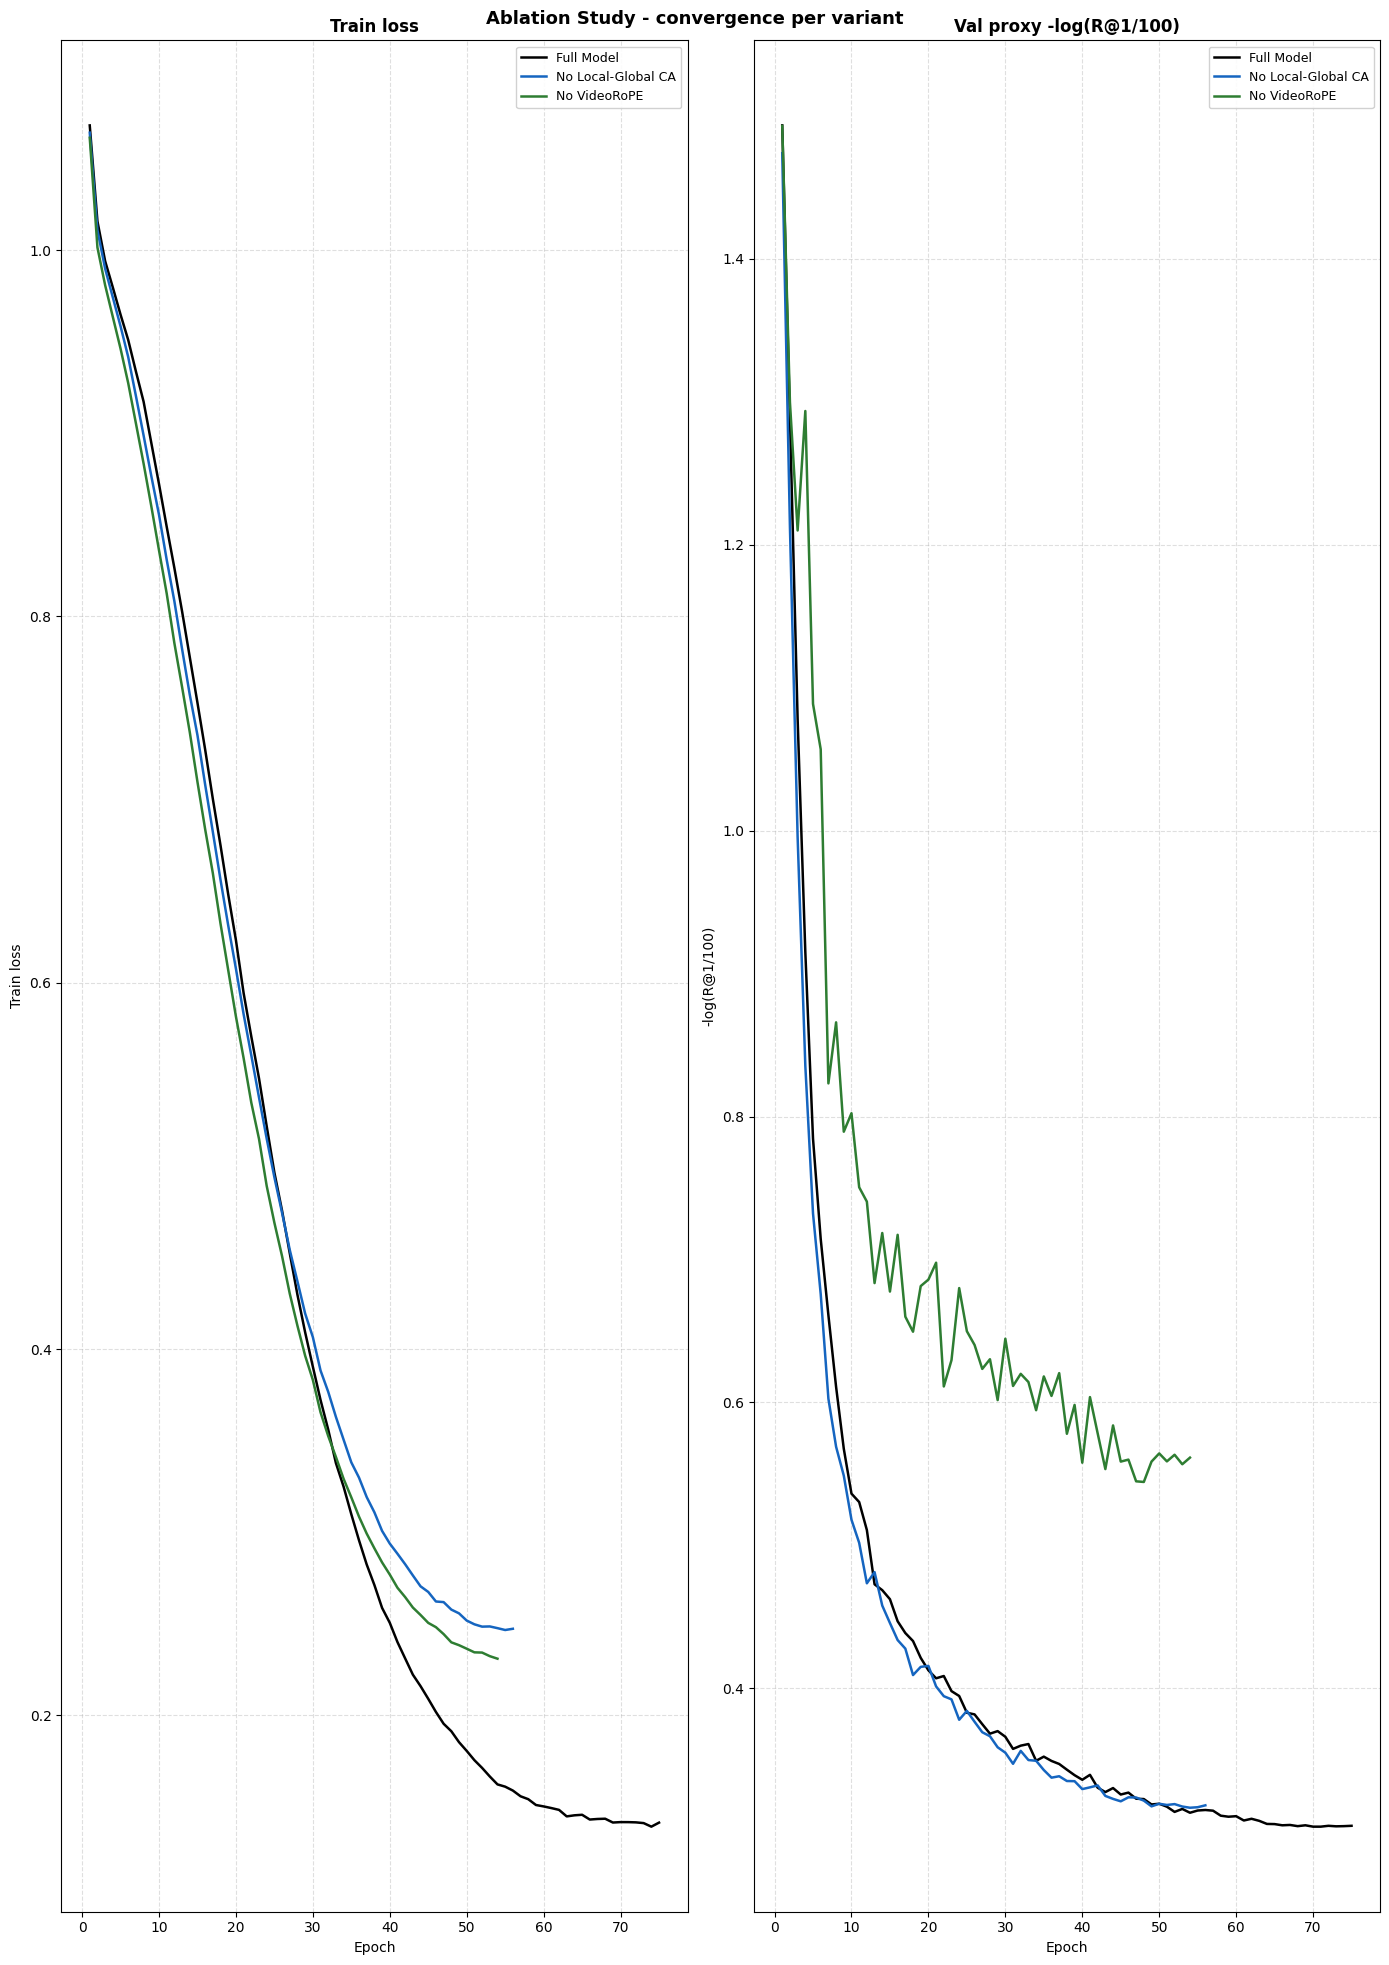

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PRETRAIN_V3_DIR = SOURCE_DIR / 'pretrain_v3_output'

def _load_log(path):
    p = Path(path)
    if not p.exists():
        print(f"[skip] log not found: {p}")
        return None
    raw = json.loads(p.read_text('utf-8'))
    rows = sorted(raw, key=lambda r: r['epoch'])
    ep = np.array([r['epoch'] for r in rows], dtype=float)
    tl = np.array([r['train_loss'] for r in rows], dtype=float)
    vl = -np.log(np.clip(np.array([r['R1'] for r in rows], dtype=float), 1e-5, 100.0) / 100.0)
    return ep, tl, vl

# Each variant -> absolute path of its training log on disk.
variants = [
    ('Full Model',          PRETRAIN_V3_DIR / 'pretrain_v3_gate_neg1_log.json',  '#000000', '-'),
    ('No Local-Global CA',  ABLATION_OUTPUT / 'ablation_no_local_global_log.json', '#1565C0', '-'),
    ('No VideoRoPE',        ABLATION_OUTPUT / 'ablation_no_videorope_log.json',    '#2E7D32', '-'),
    # ('AdaptFilter',         ABLATION_OUTPUT / 'ablation_adaptfilter_log.json',     '#C62828', '-'),
    # ('No NarrLoss',         ABLATION_OUTPUT / 'ablation3_no_narr_log.json',        '#F9A825', '-'),
    # ('No Gate',             ABLATION_OUTPUT / 'ablation_no_gate_log.json',         '#6A1B9A', '-'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 20))
for name, path, color, ls in variants:
    res = _load_log(path)
    if res is None: continue
    ep, tl, vl = res
    axes[0].plot(ep, tl, color=color, lw=1.8, linestyle=ls, label=name)
    axes[1].plot(ep, vl, color=color, lw=1.8, linestyle=ls, label=name)
for ax, title, ylabel in zip(axes,
                              ['Train loss', 'Val proxy -log(R@1/100)'],
                              ['Train loss', '-log(R@1/100)']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
axes[0].legend(loc='upper right', fontsize=9, framealpha=0.9)
axes[1].legend(loc='upper right', fontsize=9, framealpha=0.9)
fig.suptitle('Ablation Study - convergence per variant', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()
